<script src="/course_model/toc.js"></script>

# K-Means Neighbors Clustering

K-Means is a popular unsupervised machine learning algorithm used for *clustering* tasks. The algorithm works by partitioning the data into K distinct clusters based on feature similarity. There is no target variable in clustering, as the goal is to group similar data points together rather than predict a specific outcome.

**Outcomes**:
- Understand the K-Means clustering algorithm
- Differentiate between supervised and unsupervised learning (i.e., dependent variable)
- Explain why K-Means does not use test/train splits 
- Explain why K-means needs scaling
- Learn how to choose the number of clusters (K) with an elbow plot
- Interpret clustering results

**Links**:
- State characteristics [template](template.ipynb) and [datafile](statelife.csv)
- Alternative datasetfile of [states](StateDemographics2.xlsx)
- Morgantown real estate [datafile](zillowmorgantown_latlong.csv)

## Algorithm Overview

K-Means is an *unsupervised learning* algorithm, meaning it does not use labeled data for training. It identifies patterns and structures in the data based on feature similarity.

The algorithm works by initializing K centroids (the center points of the clusters) and iteratively assigning data points to the nearest centroid and updating the centroids based on the assigned points.

Key Concepts:
- We do not use data splitting (train/test), as there is no *dependent variable*. 
- When teaching, we will sometimes compare the clusters against an outcome variable to see how well the clusters align. However, this is not likely to be done with real-world problems, where you want to find natural groupings.


Problems:
- K-Means assumes that clusters are spherical and equally sized, which may not always be the case in real-world data.
- Choosing K is a subjective process.
    - The elbow method is a common technique to help choose K by plotting the explained variance as a function of K and looking for an "elbow" point where the rate of decrease sharply changes
    - However, there is no definitive way to choose K, and it may require domain knowledge or experimentation.
- Scaling features
    - Feature scaling is important for distance-based algorithms like KNN
    - Otherwise, features with larger scales can dominate the distance calculations (for example, age in years vs. income in thousands of dollars)
    - Standardizing features can be done using techniques like Min-Max scaling or Z-score normalization.

Interpretation:
- Overall model:
    - No accuracy measures! There is no dependent variable (except when teaching).
    - We can visualize the clusters using scatter plots or other dimensionality reduction techniques (e.g., PCA) to see how well the clusters are separated.
- Individual predictions:
    - We can evaluate the clustering quality using metrics like inertia (sum of squared distances to nearest centroid). 
        - Lower inertia indicates better-defined clusters.

### Step 1: Load and Explore the Data

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, confusion_matrix


# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Create a DataFrame for easier manipulation
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = iris.target_names[y]

df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


### Step 2: Standardize the Features

Standardization is crucial for K-Means because the algorithm is distance-based. Features with larger scales will dominate the distance calculations.

In [2]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original data - first sample:")
print(X[0])
print("\nStandardized data - first sample:")
print(X_scaled[0])
print("\nMean of standardized features (should be ~0):")
print(X_scaled.mean(axis=0))
print("\nStd of standardized features (should be ~1):")
print(X_scaled.std(axis=0))

Original data - first sample:
[5.1 3.5 1.4 0.2]

Standardized data - first sample:
[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]

Mean of standardized features (should be ~0):
[-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]

Std of standardized features (should be ~1):
[1. 1. 1. 1.]


### Step 3: Find Optimal Number of Clusters (Elbow Method)

The Elbow Method helps determine the optimal number of clusters (K) by plotting the inertia (within-cluster sum of squares) against different K values.

The inertia is the *sum of squared distances* between each *point* and its assigned *cluster center*. As K increases, inertia decreases because points are closer to their cluster centers. The goal is to find the "elbow" point where the rate of decrease sharply changes, indicating a suitable K.


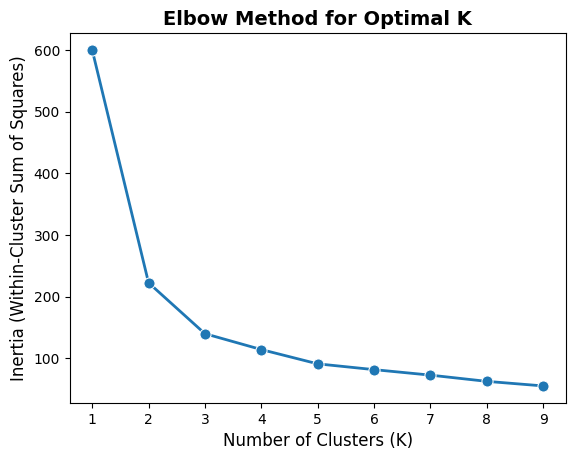

In [3]:
# Plot inertia for different numbers of clusters
import seaborn as sns
import matplotlib.pyplot as plt

inertias = []
range_tested = range(1, 10)

for k in range_tested:
    # K-Means clustering function uses a given number of clusters, a random variable for reproducibility, 
    # and n_init for stability (number of initializations, meaning the algorithm will run multiple times 
    # with different centroid seeds)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot the elbow curve as a single plot
sns.lineplot(x=range_tested, y=inertias, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.show()

### Step 4: Build and Fit the K-Means Model

In [4]:
# Create and fit K-Means model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to the dataframe
df['cluster'] = cluster_labels

print("Cluster Centers (standardized):")
print(kmeans.cluster_centers_)
print("\nCluster Distribution:")
print(df['cluster'].value_counts().sort_index())
print("\nSilhouette Score:", silhouette_score(X_scaled, cluster_labels))

Cluster Centers (standardized):
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]

Cluster Distribution:
cluster
0    53
1    50
2    47
Name: count, dtype: int64

Silhouette Score: 0.45994823920518635


### Step 5: Visualize the Clusters

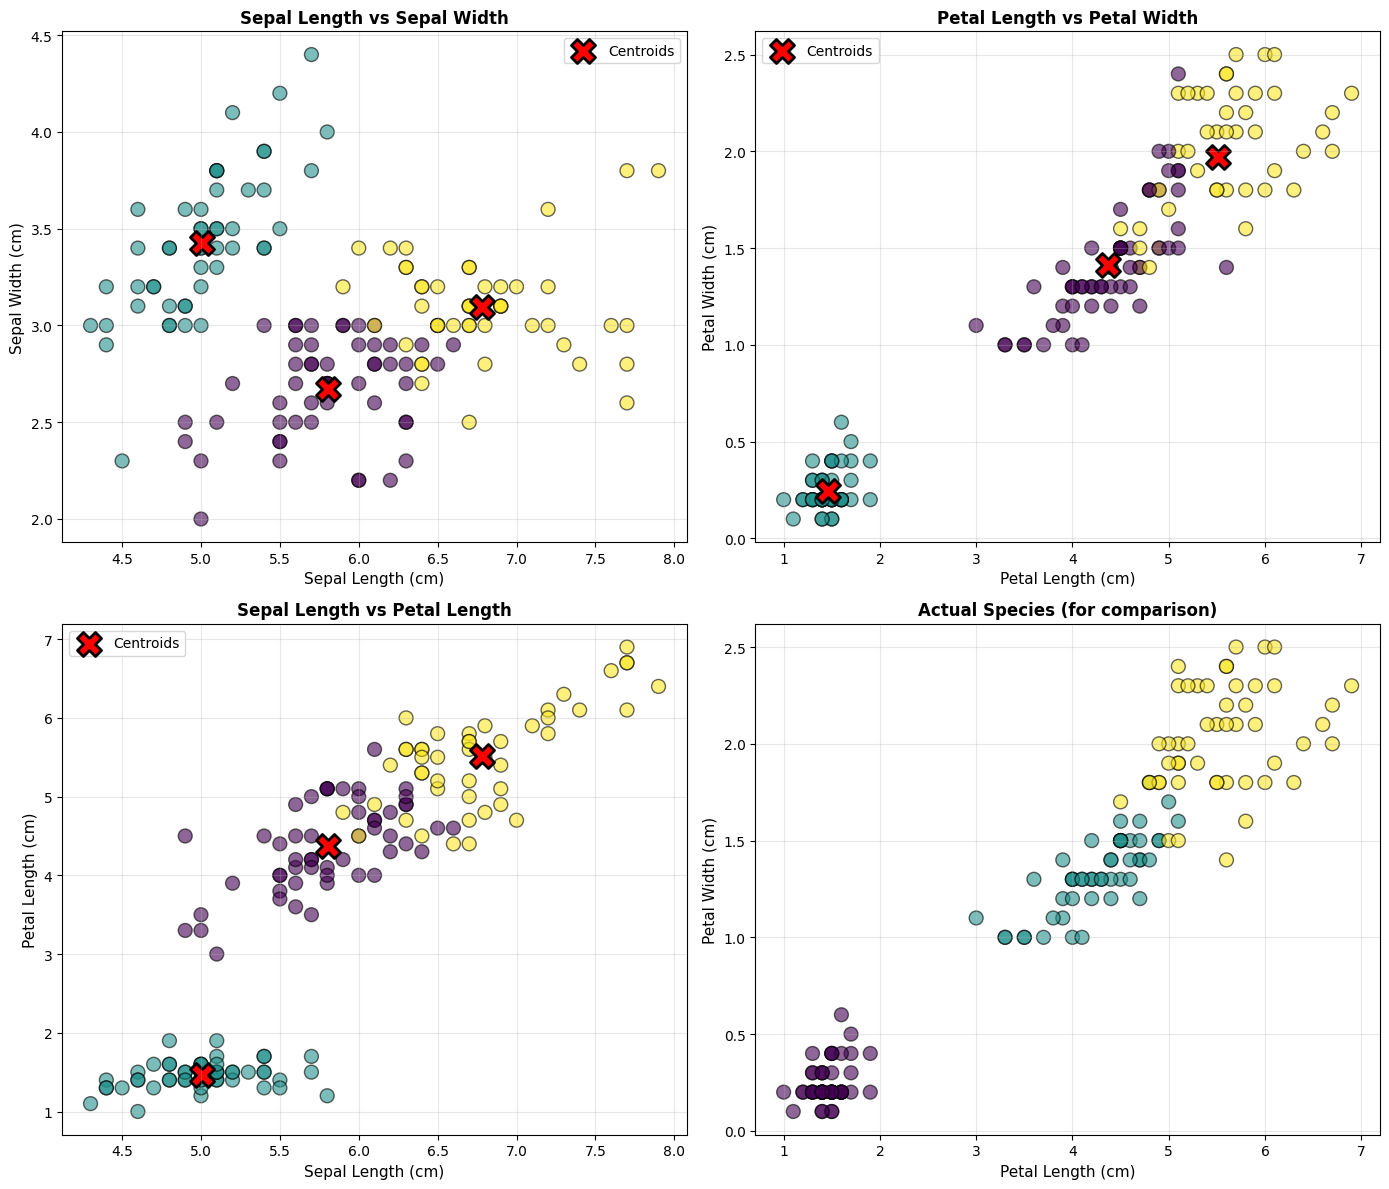

In [5]:
# Create scatter plots for different feature combinations
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Sepal Length vs Sepal Width
ax = axes[0, 0]
scatter1 = ax.scatter(df['sepal length (cm)'], df['sepal width (cm)'], 
                      c=df['cluster'], cmap='viridis', s=100, alpha=0.6, edgecolors='black')
ax.scatter(scaler.inverse_transform(kmeans.cluster_centers_)[:, 0],
           scaler.inverse_transform(kmeans.cluster_centers_)[:, 1],
           c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centroids')
ax.set_xlabel('Sepal Length (cm)', fontsize=11)
ax.set_ylabel('Sepal Width (cm)', fontsize=11)
ax.set_title('Sepal Length vs Sepal Width', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Petal Length vs Petal Width
ax = axes[0, 1]
scatter2 = ax.scatter(df['petal length (cm)'], df['petal width (cm)'], 
                      c=df['cluster'], cmap='viridis', s=100, alpha=0.6, edgecolors='black')
ax.scatter(scaler.inverse_transform(kmeans.cluster_centers_)[:, 2],
           scaler.inverse_transform(kmeans.cluster_centers_)[:, 3],
           c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centroids')
ax.set_xlabel('Petal Length (cm)', fontsize=11)
ax.set_ylabel('Petal Width (cm)', fontsize=11)
ax.set_title('Petal Length vs Petal Width', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Sepal Length vs Petal Length
ax = axes[1, 0]
scatter3 = ax.scatter(df['sepal length (cm)'], df['petal length (cm)'], 
                      c=df['cluster'], cmap='viridis', s=100, alpha=0.6, edgecolors='black')
ax.scatter(scaler.inverse_transform(kmeans.cluster_centers_)[:, 0],
           scaler.inverse_transform(kmeans.cluster_centers_)[:, 2],
           c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centroids')
ax.set_xlabel('Sepal Length (cm)', fontsize=11)
ax.set_ylabel('Petal Length (cm)', fontsize=11)
ax.set_title('Sepal Length vs Petal Length', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Comparison with actual species
ax = axes[1, 1]
species_colors = {'setosa': 0, 'versicolor': 1, 'virginica': 2}
scatter4 = ax.scatter(df['petal length (cm)'], df['petal width (cm)'], 
                      c=df['species'].map(species_colors), cmap='viridis', 
                      s=100, alpha=0.6, edgecolors='black')
ax.set_xlabel('Petal Length (cm)', fontsize=11)
ax.set_ylabel('Petal Width (cm)', fontsize=11)
ax.set_title('Actual Species (for comparison)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Step 6: Evaluate Model Performance

Since we have the actual species labels, we can compare our clusters with the true labels.

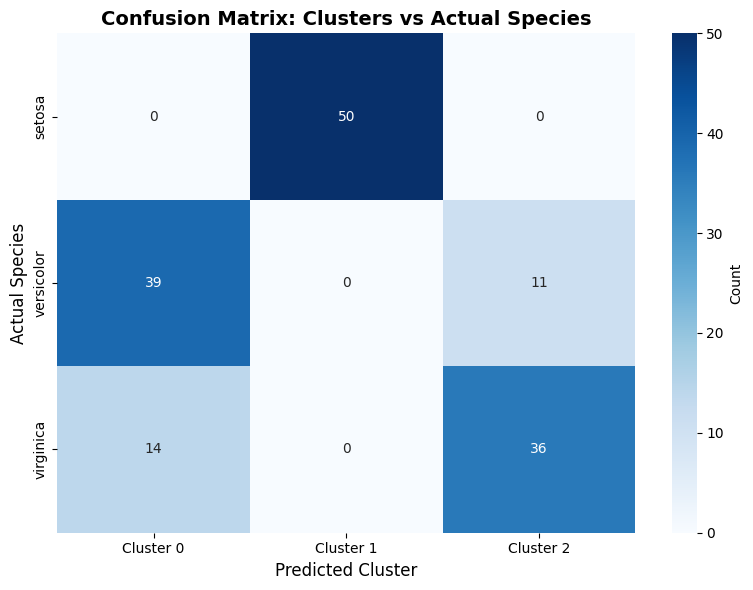

Cluster composition by species:
cluster      0   1   2
species               
setosa       0  50   0
versicolor  39   0  11
virginica   14   0  36

Analysis:
Cluster 0: Mainly versicolor (73.6% purity)
Cluster 1: Mainly setosa (100.0% purity)
Cluster 2: Mainly virginica (76.6% purity)


In [6]:
# Create confusion matrix
cm = confusion_matrix(y, cluster_labels)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cluster 0', 'Cluster 1', 'Cluster 2'],
            yticklabels=iris.target_names, cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Cluster', fontsize=12)
plt.ylabel('Actual Species', fontsize=12)
plt.title('Confusion Matrix: Clusters vs Actual Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate cluster purity
cluster_species = pd.crosstab(df['species'], df['cluster'])
print("Cluster composition by species:")
print(cluster_species)
print("\n" + "="*50)
print("Analysis:")
print("="*50)
for cluster in range(3):
    dominant_species = cluster_species[cluster].idxmax()
    purity = cluster_species[cluster].max() / cluster_species[cluster].sum()
    print(f"Cluster {cluster}: Mainly {dominant_species} ({purity:.1%} purity)")